# Analysis of GRB 080916C with GBM

In [1]:
import warnings
warnings.simplefilter("ignore")
from threeML import *
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u

22:24:12 WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=13987235;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=13987236;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

22:24:12 INFO      Starting 3ML!                                                                     ]8;id=13987243;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13987244;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=13987250;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13987251;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=13987257;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13987258;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#46\46]8;;\

         WARNING    to disable these messages, turn off start_warning in your config file            ]8;id=13987264;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13987265;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#47\47]8;;\

...

         WARNING   Multinest minimizer not available                                           ]8;id=13987279;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=13987280;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/minimizer/minimization.py#1218\1218]8;;\

         WARNING   PyGMO is not available                                                      ]8;id=13987286;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=13987287;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=13987293;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13987294;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=13987299;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13987300;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=13987305;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13987306;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

### Examining the GBM Catalog and getting some info

In [2]:
gbm_catalog = FermiGBMBurstCatalog()

In [3]:
source_name = "GRB080916009"

In [4]:
gbm_catalog.query_sources(source_name)

name,ra,dec,trigger_time,t90
object,float64,float64,float64,float64
GRB080916009,119.800,-56.600,54725.0088613,62.977


In [5]:
grb_info = gbm_catalog.get_detector_information()[source_name]
grb_info

{'source': {'fluence': '1.280000-64.257000', 'peak': '2.048000-3.072000'},
 'background': {'pre': '-40.100000--6.250000',
  'post': '105.210000-146.350000',
  'full': '-40.100000--6.250000,105.210000-146.350000'},
 'trigger': 'bn080916009',
 'detectors': array(['n3', 'n4', 'b0'], dtype='<U2'),
 'best fit model': {'fluence': 'sbpl', 'peak': 'comp'},
 'ra': 119.8,
 'dec': -56.6}

In [6]:
ra = grb_info["ra"]
dec = grb_info["dec"]
trigger_name = grb_info["trigger"]
gbm_detectors = grb_info["detectors"]
source_interval = grb_info["source"]["fluence"]
background_interval = grb_info["background"]["full"]
best_fit_model = grb_info["best fit model"]["fluence"]

### Downloading the data

In [7]:
dload = download_GBM_trigger_data(trigger_name, detectors=gbm_detectors)

22:24:19 INFO      file glg_cspec_n3_bn080916009_v01.pha is already downloaded!           ]8;id=13987313;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987314;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

22:24:23 INFO      file glg_cspec_n3_bn080916009_v00.rsp2 is already downloaded!          ]8;id=13987319;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987320;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

22:24:24 INFO      file glg_tte_n3_bn080916009_v01.fit is already downloaded!             ]8;id=13987325;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987326;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

22:24:25 INFO      file glg_cspec_n4_bn080916009_v01.pha is already downloaded!           ]8;id=13987331;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987332;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

         INFO      file glg_cspec_n4_bn080916009_v00.rsp2 is already downloaded!          ]8;id=13987337;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987338;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

22:24:26 INFO      file glg_tte_n4_bn080916009_v01.fit is already downloaded!             ]8;id=13987343;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987344;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

22:24:27 INFO      file glg_cspec_b0_bn080916009_v01.pha is already downloaded!           ]8;id=13987349;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987350;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

         INFO      file glg_cspec_b0_bn080916009_v00.rsp2 is already downloaded!          ]8;id=13987355;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987356;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

22:24:28 INFO      file glg_tte_b0_bn080916009_v01.fit is already downloaded!             ]8;id=13987361;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=13987362;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#191\191]8;;\

## Time Integrated Analysis

### Fitting the background and setting up the plugins with TimeSeriesBuilder

In [8]:
fluence_plugins = []
time_series = {}
for det in gbm_detectors:
    
    # Use CSPEC data to fit the background using the background selections. 
    # We use CSPEC because it has a longer duration for fitting the background.
    
    ts_cspec = TimeSeriesBuilder.from_gbm_cspec_or_ctime(
        det, cspec_or_ctime_file=dload[det]["cspec"], rsp_file=dload[det]["rsp"]
    )

    ts_cspec.set_background_interval(*background_interval.split(","))
    # The background is saved to an HDF5 file that stores the polynomial coefficients and selections
    ts_cspec.save_background(f"{det}_bkg.h5", overwrite=True)

    # We use TTE data for the actual spectral analysis
    ts_tte = TimeSeriesBuilder.from_gbm_tte(
        det,
        tte_file=dload[det]["tte"],
        rsp_file=dload[det]["rsp"],
        restore_background=f"{det}_bkg.h5",
    )

    time_series[det] = ts_tte

    # The source selection from the catalog is set
    ts_tte.set_active_time_interval(source_interval)

    # The plugin for the time integrated analysis is created for each detector
    fluence_plugin = ts_tte.to_spectrumlike()

    # Standard GBM channel selections for spectral analysis
    if det.startswith("b"):
        fluence_plugin.set_active_measurements("250-30000")

    else:
        fluence_plugin.set_active_measurements("9-900")

    fluence_plugin.rebin_on_background(1.0)

    fluence_plugins.append(fluence_plugin)

         WARNING   The default choice for MATRIX extension failed:KeyError("Extension ('MATRIX', 1) ]8;id=13987369;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=13987370;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#450\450]8;;\
                  not found.")available: None 'EBOUNDS' 'SPECRESP MATRIX' 'SPECRESP MATRIX'                        
                  'SPECRESP MATRIX'                                                                                

         WARNING   No TLMIN keyword found. This DRM does not follow OGIP standards. Assuming        ]8;id=13987376;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=13987377;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#576\576]8;;\
                  TLMIN=1                                                                                          

         WARNING   Minimum MC energy (5.0) is larger than minimum EBOUNDS energy                    ]8;id=13987383;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=13987384;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#133\133]8;;\
                  (4.267000198364258)                                                                              

Loading PHAII Spectra:   0%|                                                    | 0/1859 [00:00<?, ?it/s]

22:24:29 WARNING   The default choice for MATRIX extension failed:KeyError("Extension ('MATRIX', 1) ]8;id=13987389;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=13987390;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#450\450]8;;\
                  not found.")available: None 'EBOUNDS' 'SPECRESP MATRIX' 'SPECRESP MATRIX'                        
                  'SPECRESP MATRIX'                                                                                

...

         INFO      Auto-probed noise models:                                                    ]8;id=13987959;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=13987960;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: poisson                                                       ]8;id=13987965;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=13987966;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: gaussian                                                       ]8;id=13987971;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=13987972;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 250-30000 translates to channels 1-119                                ]8;id=13987977;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=13987978;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      Now using 119 bins                                                          ]8;id=13987983;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=13987984;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#1706\1706]8;;\

### Viewing the lightcurves

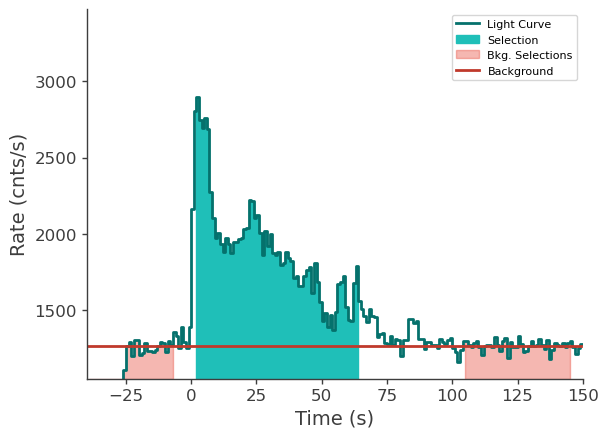

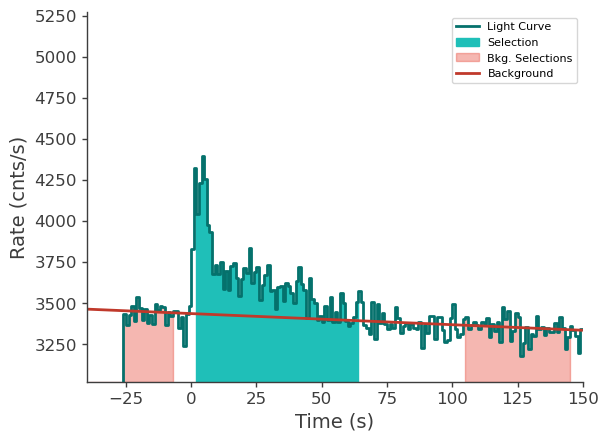

In [9]:
time_series['n3'].view_lightcurve(-40, 150);
time_series['b0'].view_lightcurve(-40, 150);

### Getting the best fit model from the catalog

In [10]:
model_catalog = gbm_catalog.get_model(best_fit_model, "fluence")["GRB080916009"]
model_catalog.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (5):
--------------------

                                value min_value max_value            unit
GRB080916009...K             0.012255       0.0      None  keV-1 s-1 cm-2
GRB080916009...alpha        -1.130424      -1.5       2.0                
GRB080916009...break_energy  309.2031      10.0      None             keV
GRB080916009...break_scale        0.3       0.0      10.0                
GRB080916009...beta         -2.096931      -5.0      -1.6                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

### Creating a new model with priors

In [11]:
sbpl = SmoothlyBrokenPowerLaw()
sbpl.alpha.prior = Truncated_gaussian(lower_bound = -1.5, upper_bound = 1, mu=-1, sigma=0.5)
sbpl.beta.prior = Truncated_gaussian(lower_bound = -5, upper_bound = -1.6, mu=-2.25, sigma=0.5)
sbpl.break_energy.prior = Log_normal(mu=2, sigma=1)
sbpl.break_energy.bounds = (None, None)
sbpl.break_scale.prior = Log_uniform_prior(lower_bound=1e-4, upper_bound=10)
sbpl.K.prior = Log_uniform_prior(lower_bound=1e-3, upper_bound=1e1)
source = PointSource(source_name, ra, dec, spectral_shape=sbpl)
model = Model(source)

22:25:00 WARNING   We have set the min_value of SmoothlyBrokenPowerLaw.break_energy to 1e-99       ]8;id=13987991;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=13987992;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py#715\715]8;;\
                  because there was a postive transform                                                            

         WARNING   We have set the min_value of SmoothlyBrokenPowerLaw.break_energy to 1e-99       ]8;id=13987997;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=13987998;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py#715\715]8;;\
                  because there was a postive transform                                                            

### Running the Bayesian analysis

In [12]:
bayes = BayesianAnalysis(model, DataList(*fluence_plugins))
bayes.set_sampler("emcee", share_spectrum=True)
bayes.sampler.setup(n_iterations=500, burn_in=10)
bayes.sample()

22:25:00 INFO      sampler set to emcee                                                    ]8;id=13988005;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/bayesian/bayesian_analysis.py\bayesian_analysis.py]8;;\:]8;id=13988006;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/bayesian/bayesian_analysis.py#186\186]8;;\

  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

22:25:06 INFO      Mean acceptance fraction: 0.5640000000000001                                ]8;id=13988013;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/bayesian/emcee_sampler.py\emcee_sampler.py]8;;\:]8;id=13988014;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/bayesian/emcee_sampler.py#145\145]8;;\

22:25:07 INFO      fit restored to maximum of posterior                                         ]8;id=13988021;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=13988022;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py#168\168]8;;\

...

,result,unit
parameter,,
GRB080916009...K,(1.463 -0.022 +0.017) x 10^-2,1 / (keV s cm2)
GRB080916009...alpha,-1.027 -0.027 +0.018,
GRB080916009...break_energy,(2.94 -0.20 +0.7) x 10^2,keV
GRB080916009...beta,-2.28 -0.19 +0.06,


Values of -log(posterior) at the minimum:

,-log(posterior)
n3,-1029.565346
n4,-1022.764536
b0,-1056.384714
total,-3108.714596


Values of statistical measures:

,statistical measures
AIC,6225.542506
BIC,6240.951324
DIC,6194.244556
PDIC,6.691298


### Plotting the corner plot

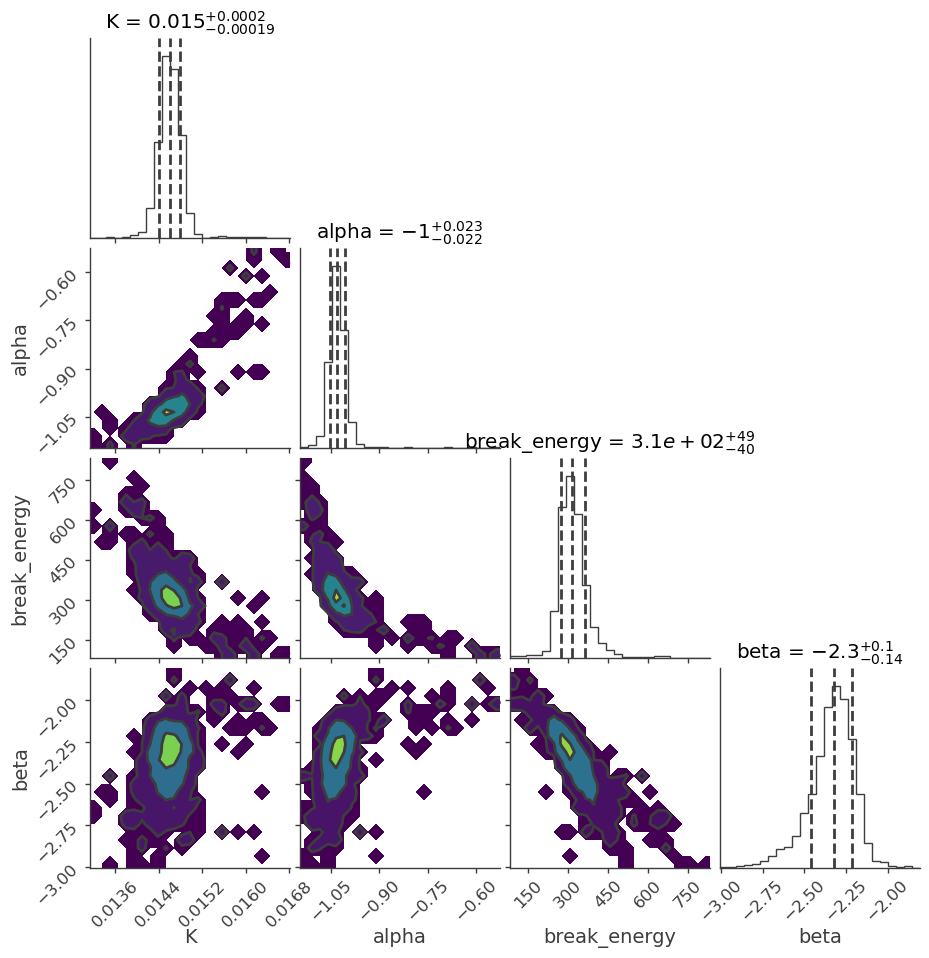

In [13]:
bayes.results.corner_plot();

### Plotting the best fit model with counts and residuals

22:25:08 INFO      fit restored to median of posterior                                          ]8;id=13988034;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=13988035;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py#157\157]8;;\

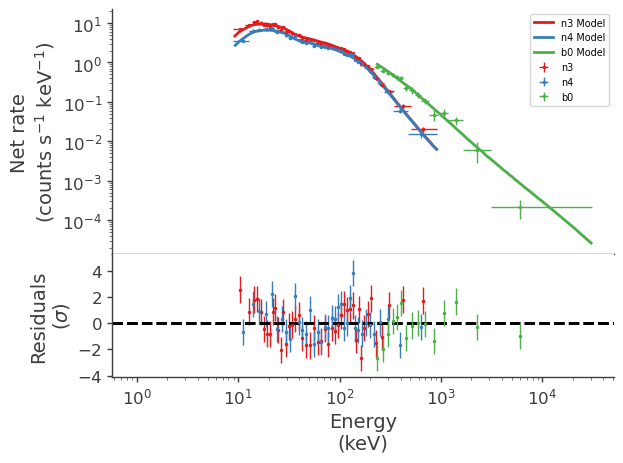

In [14]:
bayes.restore_median_fit()
fig = display_spectrum_model_counts(bayes, min_rate=10)

### Plotting the time-integrated spectrum

processing Bayesian analyses:   0%|                                                | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

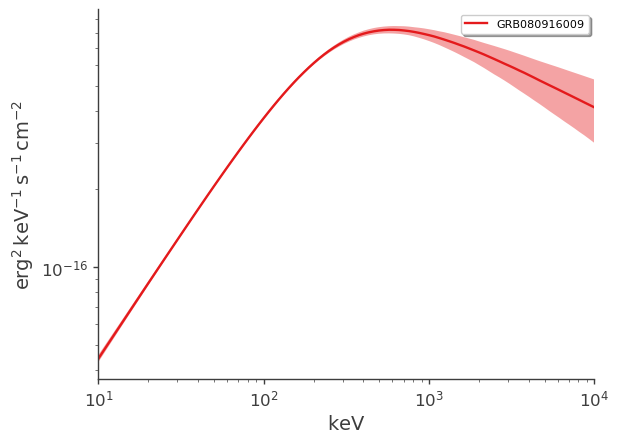

In [15]:
fig = plot_spectra(bayes.results, ene_min=10, ene_max=1e4, flux_unit="erg2/(cm2 s keV)", energy_unit="keV")

### Calculating the total flux

In [16]:
flux = bayes.results.get_flux(ene_min=10 * u.keV, ene_max=1 * u.MeV, flux_unit="erg/cm2/s")
flux

processing Bayesian analyses:   0%|                                                | 0/1 [00:00<?, ?it/s]

,flux,low bound,hi bound
GRB080916009: total,1.2119495064196049e-06 erg / (s cm2),1.192832652289979e-06 erg / (s cm2),1.2307906586067425e-06 erg / (s cm2)


# Time Resolved Analysis

### Creating temporal binning using the Bayesian Block algorithm

In [17]:
n3 = time_series["n3"]

In [18]:
n3.create_time_bins(0, 60, method="bayesblocks", use_background=True, p0=0.01)

22:26:31 INFO      Created 10 bins via bayesblocks                                       ]8;id=13988041;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py\time_series_builder.py]8;;\:]8;id=13988042;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py#632\632]8;;\

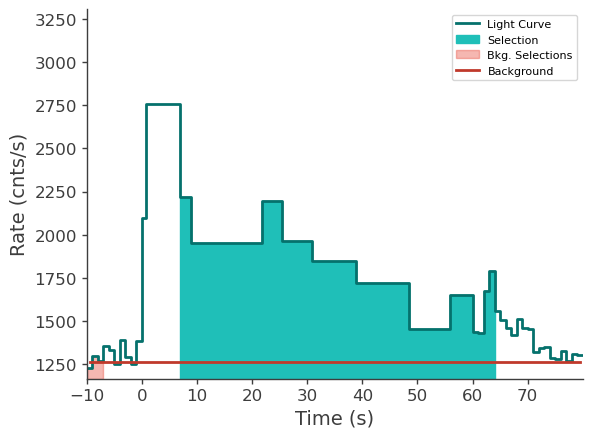

In [27]:
n3.view_lightcurve(-10, 80, use_binner=True);

### Creating the new plugins with the chosen binning

In [20]:
time_resolved_plugins = {}

for k, v in time_series.items():
    v.read_bins(n3)
    time_resolved_plugins[k] = v.to_spectrumlike(from_bins=True)

         INFO      Created 10 bins via custom                                            ]8;id=13988047;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py\time_series_builder.py]8;;\:]8;id=13988048;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py#632\632]8;;\

Creating plugins:   0%|                                                           | 0/10 [00:00<?, ?it/s]

         WARNING   Minimum MC energy (5.0) is larger than minimum EBOUNDS energy                    ]8;id=13988053;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=13988054;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#133\133]8;;\
                  (4.267000198364258)                                                                              

         INFO      Interval set to 1.28-64.257 for n3                                    ]8;id=13988059;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py\time_series_builder.py]8;;\:]8;id=13988060;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py#274\274]8;;\

         INFO      Created 10 bins via custom                                            ]8;id=13988065;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py\time_series_builder.py]8;;\:]8;id=13988066;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py#632\632]8;;\

...

         WARNING   Minimum MC energy (5.0) is larger than minimum EBOUNDS energy                    ]8;id=13988071;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=13988072;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#133\133]8;;\
                  (4.369999885559082)                                                                              

         INFO      Interval set to 1.28-64.257 for n4                                    ]8;id=13988077;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py\time_series_builder.py]8;;\:]8;id=13988078;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py#274\274]8;;\

         INFO      Created 10 bins via custom                                            ]8;id=13988083;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py\time_series_builder.py]8;;\:]8;id=13988084;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py#632\632]8;;\

Creating plugins:   0%|                                                           | 0/10 [00:00<?, ?it/s]

22:26:32 INFO      Interval set to 1.28-64.257 for b0                                    ]8;id=13988089;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py\time_series_builder.py]8;;\:]8;id=13988090;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/time_series_builder.py#274\274]8;;\

### Setting up the model

In [28]:
band = Band()
band.alpha.prior = Truncated_gaussian(lower_bound=-1.5, upper_bound=1, mu=-1, sigma=0.5)
band.beta.prior = Truncated_gaussian(lower_bound=-5, upper_bound=-1.6, mu=-2, sigma=0.5)
band.xp.prior = Log_normal(mu=2, sigma=1)
band.xp.bounds = (None, None)
band.K.prior = Log_uniform_prior(lower_bound=1e-10, upper_bound=1e3)
source = PointSource(source_name, ra, dec, spectral_shape=band)
band_model = Model(source)

22:34:39 WARNING   We have set the min_value of Band.xp to 1e-99 because there was a postive       ]8;id=13988291;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=13988292;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py#715\715]8;;\
                  transform                                                                                        

         WARNING   We have set the min_value of Band.xp to 1e-99 because there was a postive       ]8;id=13988297;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=13988298;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py#715\715]8;;\
                  transform                                                                                        

### Performing a MLE analysis for each time interval

In [30]:
analysis = []
for interval in range(4):
    # clone the model above so that we have a separate model for each fit

    this_model = clone_model(band_model)

    # for each detector set up the plugin for this time interval

    this_data_list = []
    for k, v in time_resolved_plugins.items():
        pi = v[interval]

        pi.rebin_on_background(1.0)

        this_data_list.append(pi)

    # create a data list

    dlist = DataList(*this_data_list)

    # set up the JointLikelihood object and perform the fit

    jl = JointLikelihood(this_model, dlist)
    jl.fit()

    # at this stage we coudl also save the analysis result to disk but we will simply hold onto them in memory

    analysis.append(jl)

22:35:51 INFO      Now using 120 bins                                                          ]8;id=13988310;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=13988311;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#1706\1706]8;;\

         INFO      Now using 119 bins                                                          ]8;id=13988316;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=13988317;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#1706\1706]8;;\

         INFO      Now using 107 bins                                                          ]8;id=13988322;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=13988323;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#1706\1706]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=13988328;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=13988329;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         WARNING   13.200000000000001 percent of samples have been thrown away because     ]8;id=13988334;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=13988335;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  they failed the constraints on the parameters. This results might not be                         
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

...

1.00,0.92,-0.95,0.35
0.92,1.00,-0.86,0.28
-0.95,-0.86,1.00,-0.49
0.35,0.28,-0.49,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
n3_interval3,743.060667
n4_interval3,731.336240
b0_interval3,764.841399
total,2239.238306


Values of statistical measures:

,statistical measures
AIC,4486.589927
BIC,4501.998744


### Displaying the results and saving them to disk

,result,unit
parameter,,
GRB080916009.spectrum.main.Band.K,(3.0 -0.5 +0.8) x 10^-2,1 / (keV s cm2)
GRB080916009.spectrum.main.Band.alpha,(-6.6 -1.4 +1.8) x 10^-1,
GRB080916009.spectrum.main.Band.xp,(4.0 -1.1 +1.4) x 10^2,keV
GRB080916009.spectrum.main.Band.beta,-2.29 -1.5 +0.35,


,result,unit
parameter,,
GRB080916009.spectrum.main.Band.K,(4.06 -0.13 +0.14) x 10^-2,1 / (keV s cm2)
GRB080916009.spectrum.main.Band.alpha,(-8.69 -0.27 +0.28) x 10^-1,
GRB080916009.spectrum.main.Band.xp,(6.5 +/- 0.6) x 10^2,keV
GRB080916009.spectrum.main.Band.beta,-2.16 -0.11 +0.09,


,result,unit
parameter,,
GRB080916009.spectrum.main.Band.K,(2.31 -0.18 +0.19) x 10^-2,1 / (keV s cm2)
GRB080916009.spectrum.main.Band.alpha,-1.09 +/- 0.06,
GRB080916009.spectrum.main.Band.xp,(7.0 -1.6 +2.9) x 10^2,keV
GRB080916009.spectrum.main.Band.beta,-2.16 -0.6 +0.21,


,result,unit
parameter,,
GRB080916009.spectrum.main.Band.K,(1.98 -0.10 +0.12) x 10^-2,1 / (keV s cm2)
GRB080916009.spectrum.main.Band.alpha,(-10.0 +/- 0.4) x 10^-1,
GRB080916009.spectrum.main.Band.xp,(4.3 -0.5 +0.6) x 10^2,keV
GRB080916009.spectrum.main.Band.beta,-1.99 -0.12 +0.09,


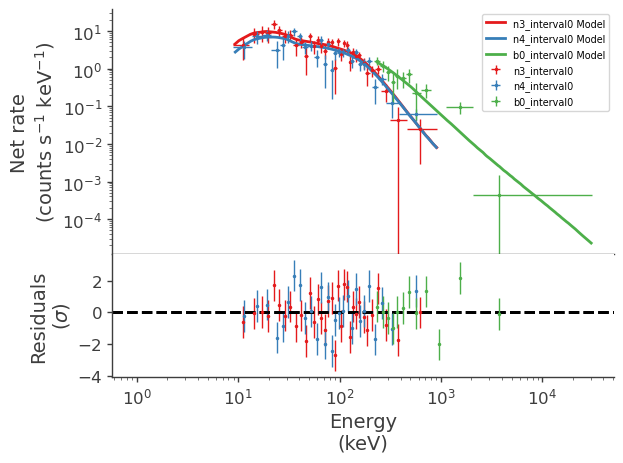

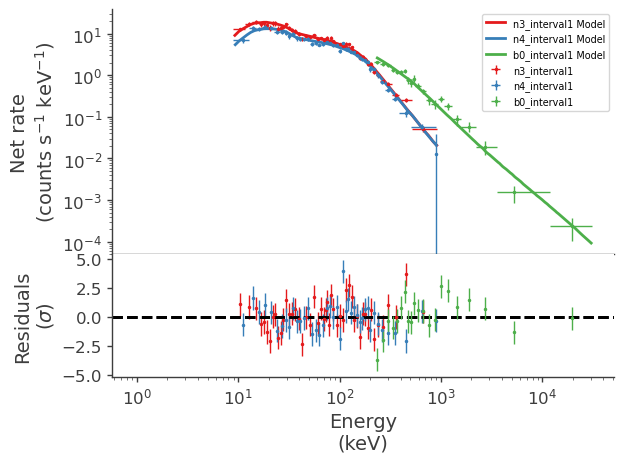

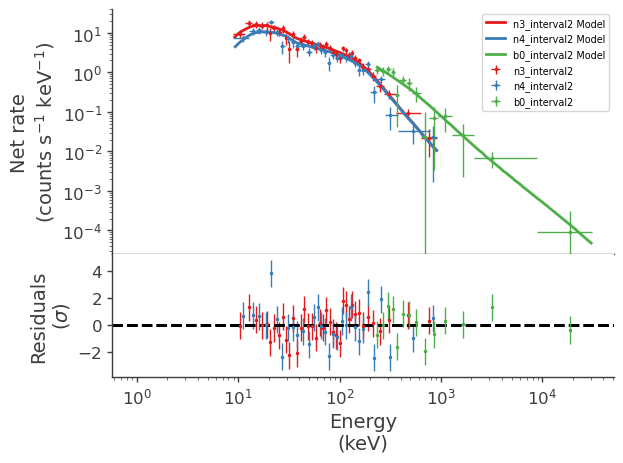

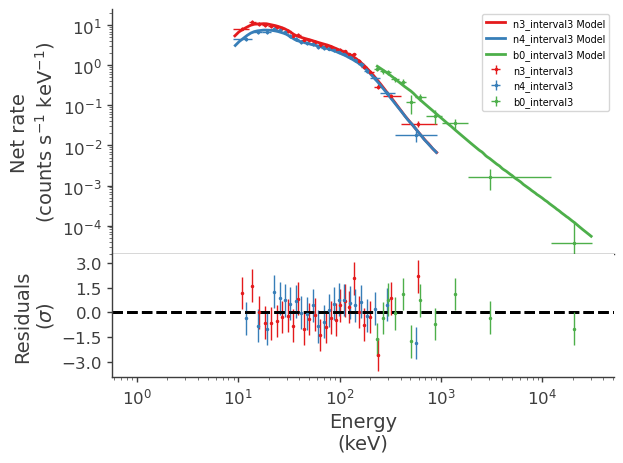

In [31]:
for i, a in enumerate(analysis):
    a.get_errors()
    a.results.write_to("results_%s_%d.fits" % (source_name, i), overwrite=True)
    display_spectrum_model_counts(a, min_rate=[20, 20, 20]);

### Plotting the best fit spectrum for each time interval

processing MLE analyses:   0%|                                                     | 0/4 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

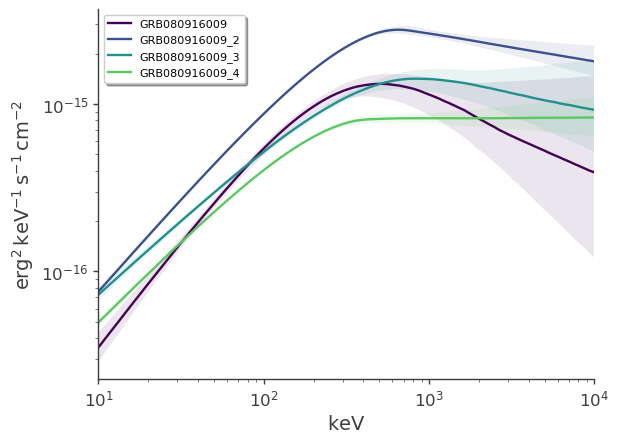

In [32]:
fig = plot_spectra(
    *[a.results for a in analysis],
    flux_unit="erg2/(cm2 s keV)",
    fit_cmap="viridis",
    contour_cmap="viridis",
    contour_style_kwargs=dict(alpha=0.1),
)

### Reloading the results from disk

In [33]:
results_reloaded = load_analysis_results("results_%s_1.fits" % source_name)
results_reloaded.get_data_frame()

,value,negative_error,positive_error,error,unit
GRB080916009.spectrum.main.Band.K,0.040608,-0.001310,0.001384,0.001347,1 / (keV s cm2)
GRB080916009.spectrum.main.Band.alpha,-0.869457,-0.027379,0.027266,0.027322,
GRB080916009.spectrum.main.Band.xp,648.249846,-56.653327,60.767569,58.710448,keV
GRB080916009.spectrum.main.Band.beta,-2.164458,-0.091914,0.094299,0.093106,


### Propagating the errors (if needed)

In [34]:
alpha = results_reloaded.get_variates("GRB080916009.spectrum.main.Band.alpha")
beta = results_reloaded.get_variates("GRB080916009.spectrum.main.Band.beta")

print("Propagating a+b, with a and b respectively:")
print(alpha)
print(beta)

print("\nThis is the result (with errors):")
res = alpha + beta
print(res)

Propagating a+b, with a and b respectively:
equal-tail: (-8.69 -0.28 +0.27) x 10^-1, hpd: (-8.69 -0.26 +0.28) x 10^-1
equal-tail: -2.16 +/- 0.09, hpd: -2.16 +/- 0.09

This is the result (with errors):
equal-tail: -3.03 -0.10 +0.11, hpd: -3.03 -0.10 +0.11
